In [1]:
from models.models import HierarchicalPanelICA
import pymc as pm
# import theano.tensor as tt

from pathlib import Path
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from insilico_stimuli.stimuli import GaborSet, CenterSurround

import pytensor.tensor as pt
seed = 42

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
data_basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40")
G_X_model_path = data_basepath / "layer3_models/layer3_340.joblib"
X_I_models_path = data_basepath / "layer2_models"

G_X_model = joblib.load(G_X_model_path)
print("G_X_model", G_X_model)
G_dim = G_X_model.n_components
print("G_dim", G_X_model.n_components)
G_X_mapping = G_X_model.mixing_
print("G_X_mapping.shape", G_X_mapping.shape)

X_I_models = []
print("Loading layer 2 models")
for entry in X_I_models_path.iterdir():
    # go through files and load joblib files
    if entry.is_file() and entry.suffix == ".joblib":
        model = joblib.load(entry)
        X_I_models.append(model)
        # print(model)

X_patch_dim = model.components_.shape[0]
print("X_patch_dim", X_patch_dim)
I_patch_dim = model.components_.shape[1]
print("I_patch_dim", I_patch_dim)


G_X_model FastICA(n_components=340, random_state=42, whiten='unit-variance')
G_dim 340
G_X_mapping.shape (360, 340)
Loading layer 2 models
X_patch_dim 40
I_patch_dim 144


In [3]:
X_I_mapping = np.array([model.mixing_ for model in X_I_models])

In [4]:
X_I_mapping.shape

(9, 144, 40)

In [5]:
# prob_model = pm.Model()
# with prob_model:
#     G = pm.Laplace("G", mu=0, b=1, shape=(G_dim))

#     X_mu = pm.Deterministic("X_mu", G_X_mapping @ G)
#     X_sigma = pm.Deterministic("X_sigma", pt.as_tensor_variable([0.1]))
#     X = pm.Normal("X", mu=X_mu, sigma=X_sigma)
#     X = X.reshape((len(X_I_models), X_patch_dim))
#     print("X", X.shape)

#     I_mu = pm.Deterministic("I_mu", X_I_mapping @ X)
#     print("I_mu", I_mu.shape)
#     # I_sigma = pm.Deterministic("I_sigma", pt.as_tensor_variable([0.1]))
#     # obs = pm.MutableData("obs", np.zeros(I_dim))
#     # I = pm.Normal(
#     #     "I",
#     #     mu=I_mu,
#     #     sigma=I_sigma,
#     #     observed=obs,
#     # )

In [6]:
hmodel = HierarchicalPanelICA(
    G_X_model=G_X_model,
    X_sigma=0.1,
    X_I_models=X_I_models,
    I_sigma=0.1,
)

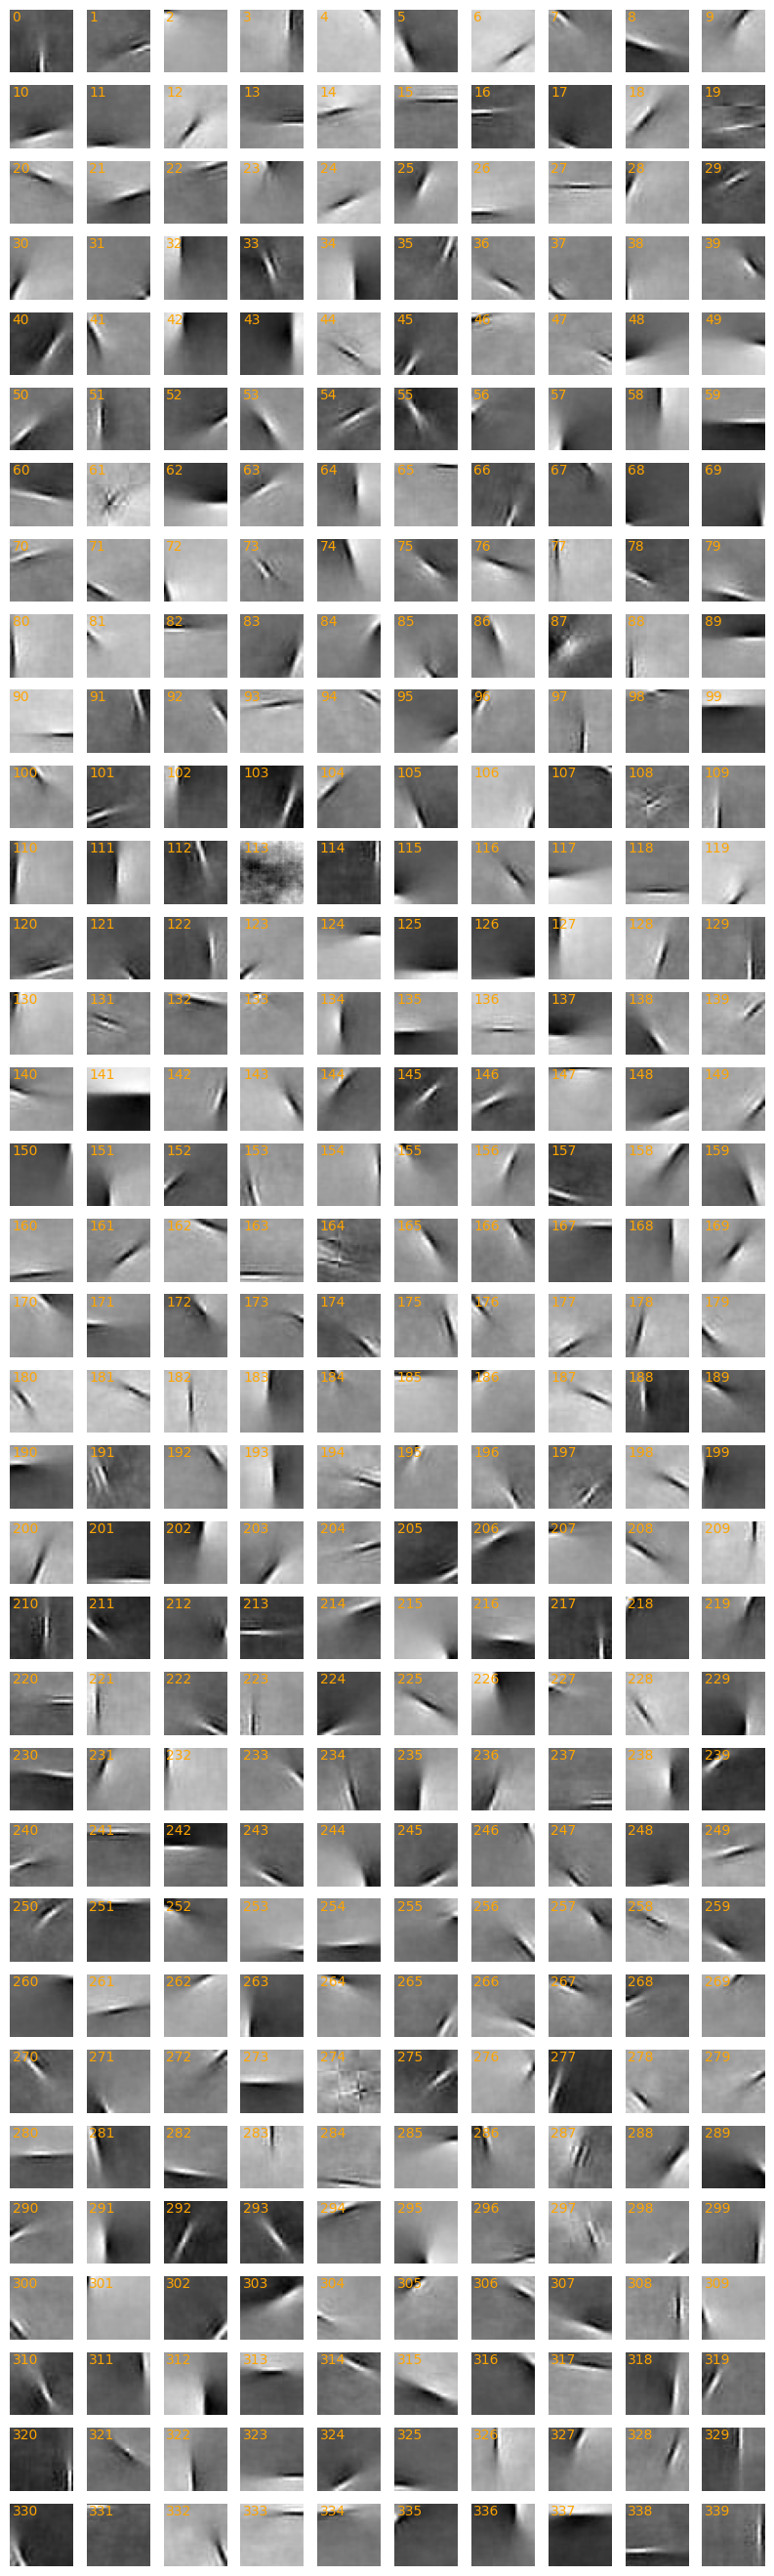

In [7]:
hmodel.visualize_learned_G()

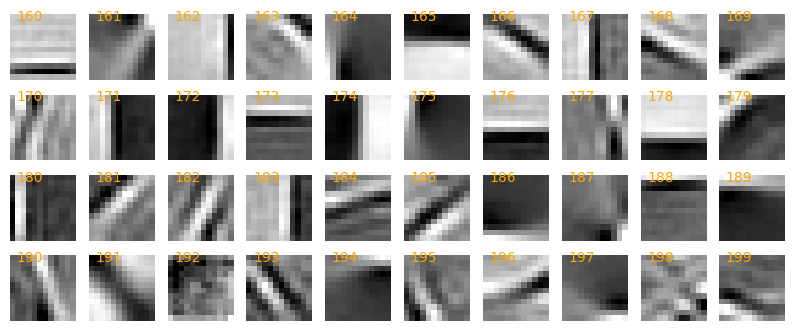

In [8]:
hmodel.visualize_center_X_mappings(
    center_model_id=4
)

In [26]:
I_side = int(np.sqrt(hmodel.I_dim))

In [27]:
MEI_183 = np.zeros((I_side, I_side))
MEI_183[12:24,12:24] = X_I_mapping[4, :, 183 - 160].reshape(
    (hmodel.I_patch_side, hmodel.I_patch_side)
)

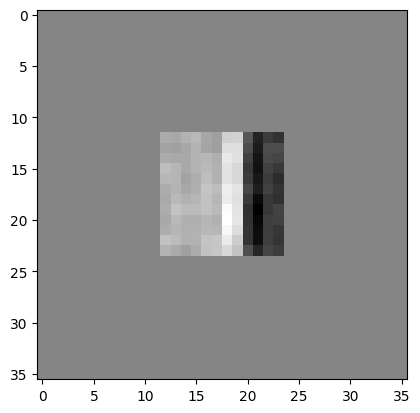

In [29]:
plt.imshow(MEI_183, cmap="gray")

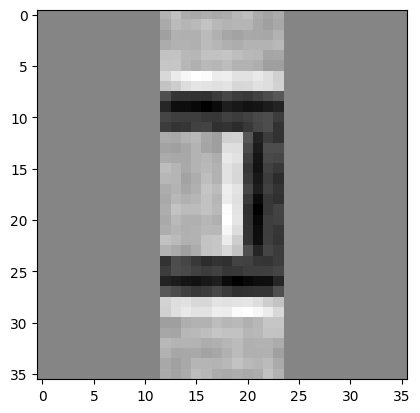

In [44]:
inhibitory_183 = np.zeros((I_side, I_side))
MEI = X_I_mapping[4, :, 183 - 160].reshape(
    (hmodel.I_patch_side, hmodel.I_patch_side)
)
inhibitory_183[12:24,12:24] = MEI
inhibitory_183[0:12, 12:24] = np.rot90(MEI, 3)
inhibitory_183[24:36, 12:24] = np.rot90(MEI, 1)
plt.imshow(inhibitory_183, cmap="gray")b

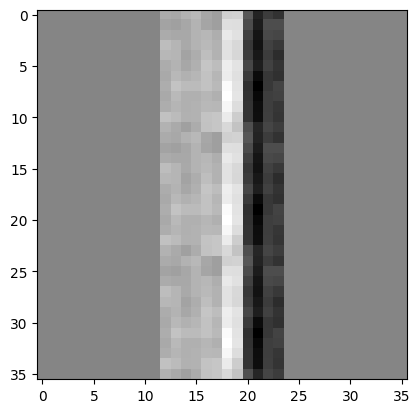

In [49]:
excitatory_183 = np.zeros((I_side, I_side))
MEI = X_I_mapping[4, :, 183 - 160].reshape(
    (hmodel.I_patch_side, hmodel.I_patch_side)
)
excitatory_183[12:24,12:24] = MEI
excitatory_183[0:12, 12:24] = MEI
excitatory_183[24:36, 12:24] = MEI
plt.imshow(excitatory_183, cmap="gray")

In [50]:
np.save("excitatory_183.npy", excitatory_183)

In [45]:
np.save("inhibitory_183.npy", inhibitory_183)

In [51]:
n_samples = 1000
tune = 1000
chains = 4
cores = 4
excitatory_183_samples = hmodel.sample_posterior(
    image=excitatory_183,
    n_samples=n_samples,
    tune=tune,
    chains=chains,
    cores=cores,
    random_seed=seed,
)
x   

reshaped_image (1296,)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [G, X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 730 seconds.


In [48]:
with open("inhibitory_183_samples.pkl", "wb") as file:
    pickle.dump(inhibitory_183_samples, file)

In [30]:
np.save("MEI_183.npy", MEI_183)

In [31]:
n_samples = 1000
tune = 1000
chains = 4
cores = 4
MEI_183_samples = hmodel.sample_posterior(
    image=MEI_183,
    n_samples=n_samples,
    tune=tune,
    chains=chains,
    cores=cores,
    random_seed=seed,
)

reshaped_image (1296,)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [G, X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1673 seconds.


In [33]:
import pickle
with open("post_samples_183_MEI.pkl", "wb") as f:
    pickle.dump(MEI_183_samples, f)

In [ ]:
prior_sample_size = 1000
idata = hmodel.sample_prior_predictive(
    n_samples=prior_sample_size,
    random_seed=seed,
)

In [ ]:
images = idata["I"] 

In [ ]:
images = idata['I']
print("images.shape", images.shape)

In [ ]:
fig, axs = plt.subplots(20, 20, figsize=(20, 20))
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(images[idx], cmap="gray")
    ax.axis("off")

In [ ]:
idata.keys()

In [ ]:
idata['X_mu'].shape

In [ ]:
ncols = 6
nrows = 7
cs_offset = 160
n_center_neurons = 40
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols, nrows), sharex=True, sharey=True)
for idx, ax in enumerate(axs.flatten()):
    if idx < n_center_neurons:
        neuron_id = idx + cs_offset
        neuron_samples = idata['X_mu'][:, neuron_id]
        neuron_mean = neuron_samples.mean()
        sns.histplot(
            neuron_samples,
            element="step",
            ax=ax,
        )
        ax.axvline(neuron_mean, color='red')
        ax.text(
            0.5,
            0.1,
            str(neuron_id),
            color="orange",
            fontsize=10,
            horizontalalignment="left",
            verticalalignment="top",
        )
        ax.text(0.8, 0.8, f"{neuron_mean*100:.1f}e-2", size=7, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.axis("off")


In [ ]:
idata['X_mu'].shape

In [ ]:
mean_X_mu = idata['X_mu'].mean(axis=0)
mean_X_mu.shape

In [ ]:
fig, ax = plt.subplots(dpi=100)
sns.histplot(
    mean_X_mu[cs_offset: cs_offset+n_center_neurons],
    element="step",
    ax=ax,
)

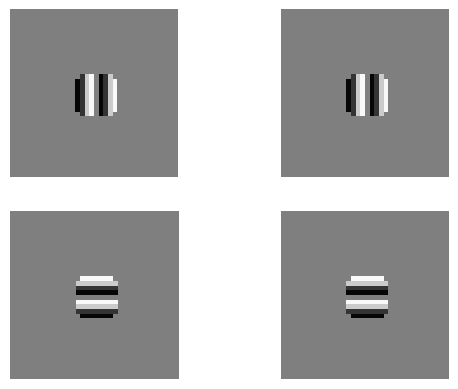

In [13]:
center_surround_params_center_only = {
    "canvas_size": [36, 36],
    "spatial_frequencies_center": [1/5],
    "spatial_frequencies_surround": [1/5],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": [0.0],
    "orientations_center": [0, np.pi/2],
    "orientations_surround": [0., np.pi/2],
    "locations": [[18, 18]],
    "sizes_total": [36],
    "sizes_center": [20/4/36],
    "sizes_surround": [20/4/36],
    "contrasts_center": [1.0],
    "contrasts_surround": [0],
}

center_surround_gabors_center_only = CenterSurround(**center_surround_params_center_only)
fig, axs = plt.subplots(2, 2, dpi=100)
for i, ax in enumerate(axs.flatten()):
    if i < center_surround_gabors_center_only.images().shape[0]:
        ax.imshow(center_surround_gabors_center_only.images()[i], cmap="gray", vmin=-1, vmax=1)
        # write the label on the left side of the subplot
        # ax.text(-0.3, 0.5, f"{i}", size=5, ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

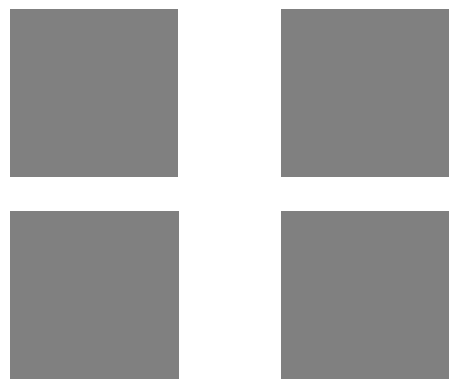

In [15]:
center_surround_params_center_only = {
    "canvas_size": [36, 36],
    "spatial_frequencies_center": [1/5],
    "spatial_frequencies_surround": [1/5],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": [0.0],
    "orientations_center": [0, np.pi/2],
    "orientations_surround": [0., np.pi/2],
    "locations": [[18, 18]],
    "sizes_total": [36],
    "sizes_center": [20/4/36],
    "sizes_surround": [20/4/36],
    "contrasts_center": [0],
    "contrasts_surround": [0],
}

center_surround_gabors_center_only = CenterSurround(**center_surround_params_center_only)
fig, axs = plt.subplots(2, 2, dpi=100)
for i, ax in enumerate(axs.flatten()):
    if i < center_surround_gabors_center_only.images().shape[0]:
        ax.imshow(center_surround_gabors_center_only.images()[i], cmap="gray", vmin=-1, vmax=1)
        # write the label on the left side of the subplot
        # ax.text(-0.3, 0.5, f"{i}", size=5, ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

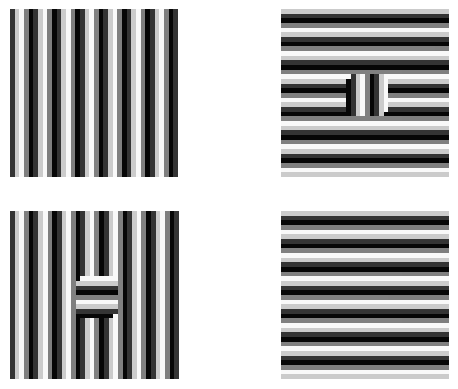

In [11]:
center_surround_params_hv = {
    "canvas_size": [36, 36],
    "spatial_frequencies_center": [1/5],
    "spatial_frequencies_surround": [1/5],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": [0.0],
    "orientations_center": [0, np.pi/2],
    "orientations_surround": [0., np.pi/2],
    "locations": [[18, 18]],
    "sizes_total": [36],
    "sizes_center": [20/4/36],
    "sizes_surround": [20/4/36],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_surround_gabors_hv = CenterSurround(**center_surround_params_hv)
fig, axs = plt.subplots(2, 2, dpi=100)
for i, ax in enumerate(axs.flatten()):
    if i < center_surround_gabors_hv.images().shape[0]:
        ax.imshow(center_surround_gabors_hv.images()[i], cmap="gray", vmin=-1, vmax=1)
        # write the label on the left side of the subplot
        # ax.text(-0.3, 0.5, f"{i}", size=5, ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

In [ ]:
center_surround_params_sl = {
    "canvas_size": [36, 36],
    "spatial_frequencies_center": [1/5],
    "spatial_frequencies_surround": [1/5],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": [0.0],
    "orientations_center": [-np.pi/4, np.pi/4],
    "orientations_surround": [-np.pi/4, np.pi/4],
    "locations": [[18, 18]],
    "sizes_total": [36],
    "sizes_center": [20/4/36],
    "sizes_surround": [20/4/36],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_surround_gabors_sl = CenterSurround(**center_surround_params_sl)
fig, axs = plt.subplots(2, 2, dpi=100)
for i, ax in enumerate(axs.flatten()):
    if i < center_surround_gabors_sl.images().shape[0]:
        ax.imshow(center_surround_gabors_sl.images()[i], cmap="gray", vmin=-1, vmax=1)
        # write the label on the left side of the subplot
        # ax.text(-0.3, 0.5, f"{i}", size=5, ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

In [ ]:
all_gabors = np.concatenate([center_surround_gabors_hv.images(), center_surround_gabors_sl.images()], axis=0)

In [ ]:
all_gabors.shape

In [ ]:
n_samples = 2
image = excitatory
tune = 2
chains = 4
cores = 4
post_samples = hmodel.sample_posterior(
    image=image,
    n_samples=n_samples,
    tune=tune,
    chains=chains,
    cores=cores,
    random_seed=seed,
)

In [ ]:
post_samples

In [ ]:
import pickle
with open("post_samples_excitatory.pkl", "wb") as f: 
    pickle.dump(post_samples, f)  

In [ ]:
with open("post_samples_excitatory.pkl", "rb") as f: 
    post_samples_read = pickle.load(f)

In [ ]:
post_samples_read['posterior']['G'].shape

In [ ]:
# generated_Is = []
# G_dim = layer3_model.n_components
# for hot_idx in range(G_dim):
#     G = np.zeros(G_dim)
#     G[hot_idx] = 1
#     G = G.reshape(1, -1)
#     # X = layer3_model.inverse_transform(G)
#     X = G @ layer3_model.mixing_.T
#     X_patches = X.reshape(1, 9, 40).transpose(1, 0, 2)
#     I_patches = []
#     for X_patch, layer2_model in zip(X_patches, layer2_model_list):
#         # I_patch = layer2_model.inverse_transform(X_patch)
#         I_patch = X_patch @ layer2_model.mixing_.T
#         I_patch = I_patch.squeeze(0).reshape(12, 12)
#         I_patches.append(I_patch)
#     I_patches = np.array(I_patches)
#     generated_Is.append(I_patches)
# generated_Is = np.array(generated_Is)
# print("generated_Is", generated_Is.shape)
# generated_Is = np.array(
#     [
#         np.vstack(
#             [
#                 np.hstack(I[i * 3 : (i + 1) * 3]) for i in range(3)
#             ]
#         ) for I in generated_Is
#     ]
# )
# print("generated_Is", generated_Is.shape)

# nrows = int(generated_Is.shape[0]/10)
# ncols = 10
# # vmin = -np.max(np.abs(generated_Is))
# # vmax = np.max(np.abs(generated_Is))
# fig, ax = plt.subplots(nrows, ncols, figsize=(ncols, nrows))
# for idx, ax in enumerate(ax.flatten()):
#     ax.imshow(generated_Is[idx], cmap="gray")
#     ax.axis("off")